# ECO764 Assignment

## Q5: Arbitrage Opportunities

### Load Data

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats as sp_stats
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import VECM, select_order, select_coint_rank
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
# ============================================================
# CELL 3 - Download raw price data
# What is downloaded:
#   GOLDBEES.NS  : SBI Gold ETF on NSE - used as Indian Gold
#                  spot price proxy (INR per gram). We multiply
#                  by 10 to get INR per 10g (MCX convention).
#   GC=F         : COMEX Gold front-month futures (USD/troy oz).
#                  We convert to INR/10g using the exchange rate.
#   INR=X        : USD to INR daily exchange rate.
# ============================================================

START = '2014-01-01'
END   = '2024-12-31'

# ── FIX: yfinance >= 0.2.x returns a 2-D DataFrame (MultiIndex columns)
# even for a single ticker. We use .squeeze() to always get a 1-D Series.
def download_series(ticker, start, end):
    raw   = yf.download(ticker, start=start, end=end,
                        auto_adjust=True, progress=False)
    close = raw['Close']
    if isinstance(close, pd.DataFrame):
        close = close.squeeze()   # (N,1) DataFrame -> (N,) Series
    close = close.squeeze()       # belt-and-suspenders: ensure 1-D
    close.name = ticker
    return close

print("Downloading Gold spot ETF (GOLDBEES.NS)...")
gold_etf      = download_series('GOLDBEES.NS', START, END)
gold_spot_raw = gold_etf * 10        # INR/gram -> INR/10g

print("Downloading USD/INR exchange rate (INR=X)...")
usd_inr       = download_series('INR=X', START, END)

print("Downloading COMEX Gold futures (GC=F)...")
gold_fut_usd  = download_series('GC=F', START, END)

# Convert COMEX futures from USD/troy oz  ->  INR/10g
# 1 troy oz = 31.1035 grams  =>  1 troy oz = 3.11035 units of 10g
TROY_OZ_PER_10G = 31.1035 / 10

# Align usd_inr to the futures trading dates before multiplying
usd_inr_aligned = usd_inr.reindex(gold_fut_usd.index).ffill()
gold_fut_inr    = gold_fut_usd * usd_inr_aligned * (1 / TROY_OZ_PER_10G)

# Verify all are genuinely 1-D before proceeding
assert gold_spot_raw.ndim == 1, f"spot is {gold_spot_raw.ndim}-D, expected 1-D"
assert usd_inr.ndim       == 1, f"usd_inr is {usd_inr.ndim}-D, expected 1-D"
assert gold_fut_inr.ndim  == 1, f"futures is {gold_fut_inr.ndim}-D, expected 1-D"

print("\nAll series confirmed 1-D. Shapes:")
print(f"  Spot ETF (INR/10g) : {gold_spot_raw.shape}")
print(f"  USD/INR rate       : {usd_inr.shape}")
print(f"  Futures (INR/10g)  : {gold_fut_inr.shape}")
print("\nSample spot values:")
print(gold_spot_raw.tail(3).to_string())


All series confirmed 1-D. Shapes:
  Spot ETF (INR/10g) : (2708,)
  USD/INR rate       : (2866,)
  Futures (INR/10g)  : (2764,)

Sample spot values:
Date
2024-12-26    640.000000
2024-12-27    642.099991
2024-12-30    640.000000


In [4]:
# ============================================================
# CELL 4 - Merge, clean and build master DataFrame
# After this cell:
#   df           : price levels with columns 'spot' and 'futures'
#   df_diff      : first differences (Delta_S and Delta_F)
#   df_logret    : daily log returns
# ============================================================

# Merge on common trading dates.
# We use pd.concat to safely align two 1-D Series into a 2-column DataFrame.
df_raw = pd.concat([gold_spot_raw.rename('spot'),
                    gold_fut_inr.rename('futures')], axis=1)
df_raw = df_raw.ffill().dropna()

# ---- Build continuous futures via Panama-canal rollover adjustment --------
# Yahoo's GC=F already rolls automatically, but large single-day price jumps
# (> 1.5%) on rollover dates create spurious gaps. We subtract those gaps
# from all prior history so the series is gapless and level-consistent.

futures_pct_chg = df_raw['futures'].pct_change().abs()
roll_dates = futures_pct_chg[futures_pct_chg > 0.015].index
print(f"Detected {len(roll_dates)} roll dates (jumps > 1.5%)")

futures_adj = df_raw['futures'].copy()
for rd in sorted(roll_dates, reverse=True):
    idx = df_raw.index.get_loc(rd)
    if idx == 0:
        continue
    gap = df_raw['futures'].iloc[idx] - df_raw['futures'].iloc[idx - 1]
    futures_adj.iloc[:idx] -= gap    # shift all prior prices down by the gap

# ---- Final master DataFrame ----------------------------------------------
df = pd.DataFrame({
    'spot'   : df_raw['spot'],
    'futures': futures_adj
}).dropna()

# First differences
df_diff = df.diff().dropna()

# Log returns
df_logret = np.log(df / df.shift(1)).dropna()

print(f"\nFinal df shape    : {df.shape}")
print(f"Date range        : {df.index[0].date()} to {df.index[-1].date()}")
print(f"Observations      : {len(df)}")
print("\ndf.head():")
print(df.head())
print("\ndf_diff.head():")
print(df_diff.head())

Detected 311 roll dates (jumps > 1.5%)

Final df shape    : (2848, 2)
Date range        : 2014-01-02 to 2024-12-30
Observations      : 2848

df.head():
                  spot       futures
Date                                
2014-01-02  274.605007  17541.845793
2014-01-03  276.529999  17895.859659
2014-01-06  276.270008  17951.541256
2014-01-07  276.114998  17815.100257
2014-01-08  274.004993  17642.358303

df_diff.head():
                spot     futures
Date                            
2014-01-03  1.924992  354.013866
2014-01-06 -0.259991   55.681597
2014-01-07 -0.155010 -136.440999
2014-01-08 -2.110004 -172.741953
2014-01-09  0.290012   95.644685


In [5]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# df = pd.read_csv("futures_data.csv", parse_dates=["Date", "Expiry"])
df = df.sort_values("Date")

# df["T"] = (df["Expiry"] - df["Date"]).dt.days / 365
df["T"] = 30 / 365
df.head()

,spot,futures,T
Date,,,
2014-01-02,274.605007,17541.845793,0.082192
2014-01-03,276.529999,17895.859659,0.082192
2014-01-06,276.270008,17951.541256,0.082192
2014-01-07,276.114998,17815.100257,0.082192
2014-01-08,274.004993,17642.358303,0.082192


### Compute Theoretical Futures Price

In [ ]:
r = 0.06
c = 0.03

df["F_theoretical"] = df["spot"] * np.exp((r + c) * df["T"])
df["Spread"] = df["futures"] - df["F_theoretical"]

df.head()

,Date,spot,futures,T,F_theoretical,Spread,CashCarry,ReverseCashCarry,F1,F2,F3,Butterfly
0,2014-01-02,274.605007,17541.845793,0.082192,276.643864,17265.201929,True,False,275.282951,275.962568,276.643864,0.001678
1,2014-01-03,276.529999,17895.859659,0.082192,278.583148,17617.276511,True,False,277.212695,277.897076,278.583148,0.001690
2,2014-01-06,276.270008,17951.541256,0.082192,278.321227,17673.220029,True,False,276.952062,277.635800,278.321227,0.001688
3,2014-01-07,276.114998,17815.100257,0.082192,278.165065,17536.935191,True,False,276.796669,277.480024,278.165065,0.001687
4,2014-01-08,274.004993,17642.358303,0.082192,276.039395,17366.318908,True,False,274.681456,275.359588,276.039395,0.001674


### Identify Arbitrage Opportunities

In [ ]:
#Identification of arbitrage opportunities

transaction_cost = 0.5

df["CashCarry"] = df["Spread"] > transaction_cost
df["ReverseCashCarry"] = df["Spread"] < -transaction_cost

df=df.reset_index()
df[["Date","Spread","CashCarry","ReverseCashCarry"]].head()

,Date,Spread,CashCarry,ReverseCashCarry
0,2014-01-02,17265.201929,True,False
1,2014-01-03,17617.276511,True,False
2,2014-01-06,17673.220029,True,False
3,2014-01-07,17536.935191,True,False
4,2014-01-08,17366.318908,True,False


### Plot Spread

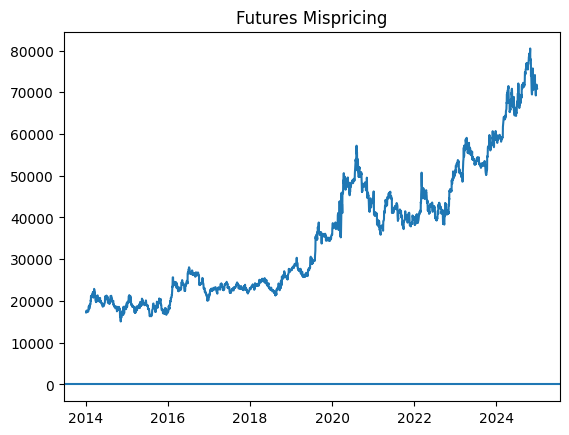

In [ ]:
# Plot for spread

plt.figure()
plt.plot(df["Date"], df["Spread"])
plt.axhline(0)
plt.title("Futures Mispricing")
plt.show()

### Butterfly Spread

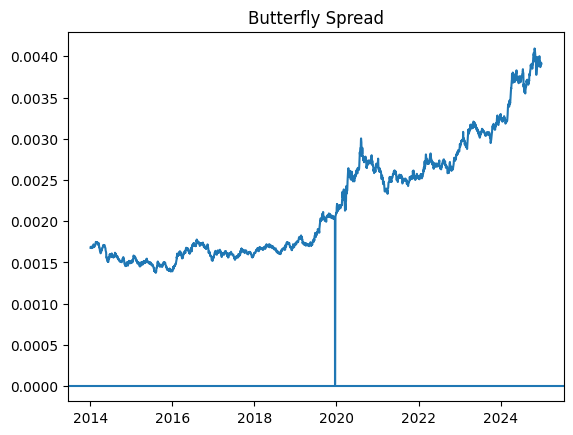

In [ ]:
import numpy as np

T1 = 10/365   # near
T2 = 20/365   # mid
T3 = 30/365   # far

df["F1"] = df["spot"] * np.exp((r+c)*T1)
df["F2"] = df["spot"] * np.exp((r+c)*T2)
df["F3"] = df["spot"] * np.exp((r+c)*T3)

# Butterfly spread
df["Butterfly"] = df["F1"] - 2*df["F2"] + df["F3"]


import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["Date"], df["Butterfly"])
plt.axhline(0)
plt.title("Butterfly Spread")
plt.show()